# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [1]:
STUDENT_NAME = "Nguyễn Tiến Đạt"  # TODO: Họ và tên
STUDENT_ID = "2410712"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Nguyễn Tiến Đạt (2410712)


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: D:\MyWorkspace\Others\mliot\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [3]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [4]:
# TODO N1
shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
predicted_classes = np.argmax(class_probabilities, axis=1)
confidence_scores = np.max(class_probabilities, axis=1)

In [5]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [6]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [7]:
# TODO N2
train_feature_mean = np.mean(X_train, axis=0)
train_feature_std = np.std(X_train, axis=0)
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [8]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [9]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [10]:
# TODO N3
correct_mask = predicted_classes == true_labels
high_confidence_mask = confidence_scores >= confidence_threshold
review_mask = (~correct_mask) | (~high_confidence_mask)
review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [11]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [12]:
# TODO N4
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
augmented_batch = normalized_batch[:, :, ::-1, :].copy()
augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**
1. Mỗi dòng đại diện cho một mẫu xe trong bộ 1985 Auto Imports.
2. Ký hiệu missing value trong CSV là `?`
3. `symboling` có nghĩa là `Mức đánh giá rủi ro bảo hiểm`

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [13]:
# TODO D1
raw_df = pd.read_csv(DATA_PATH, keep_default_na=False)
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == "?").sum().sum()

print(raw_shape)
print(raw_missing_marker_count)

(205, 26)
59


## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [14]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [15]:
# TODO D2
df_clean = raw_df.replace("?", np.nan).copy()
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])

missing_by_column = df_clean.isna().sum().sort_values(ascending=False)

print(missing_by_column)

normalized_losses    41
stroke                4
price                 4
bore                  4
horsepower            2
peak_rpm              2
num_doors             2
symboling             0
fuel_type             0
make                  0
wheel_base            0
engine_location       0
drive_wheels          0
body_style            0
aspiration            0
length                0
height                0
width                 0
fuel_system           0
engine_size           0
num_cylinders         0
engine_type           0
curb_weight           0
compression_ratio     0
city_mpg              0
highway_mpg           0
dtype: int64


### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

- Không nên fill tất cả numeric columns bằng cùng một giá trị vì mỗi cột có ý nghĩa và thang đo khác nhau.
- `price` là biến quan trọng nằm trong core analysis column, chỉ thiếu 4/205 giá trị, nên drop phù hợp hơn vì fill không đúng sẽ dễ gây sai lệch dữ liệu.
- `normalized_losses` thiếu nhiều dữ liệu nên các phân tích liên quan đến cột này sẽ kém tin cậy hơn vì phản ảnh không đúng thực tế và ảnh hưởng đến quá trình thống kê.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [16]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [17]:
# TODO D3
analysis_df = df_clean[AUTO_FEATURES].dropna().copy()
X_auto = analysis_df.to_numpy(dtype=np.float64)
auto_feature_mean = X_auto.mean(axis=0)
auto_feature_std = X_auto.std(axis=0)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

print(X_auto_scaled)

[[-0.01548585  0.07625546  0.20296699 -0.65277647 -0.53912772  0.03160942]
 [-0.01548585  0.07625546  0.20296699 -0.65277647 -0.53912772  0.40918671]
 [ 0.51484142  0.60449348  1.35087746 -0.96354805 -0.68549391  0.40918671]
 ...
 [ 0.87932089  1.10872067  0.81696561 -1.11893383 -1.12459248  1.03555038]
 [ 1.27465576  0.43641775  0.06948903  0.12415246 -0.53912772  1.15931531]
 [ 0.97574403  0.34037447  0.28305377 -0.96354805 -0.8318601   1.17879101]]


## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [18]:
# TODO D4
price_index = AUTO_FEATURES.index("price")
price_values = X_auto[:, price_index]
price_z = (price_values - price_values.mean()) / price_values.std()
price_outlier_mask = np.abs(price_z) > 2
price_outliers = analysis_df.loc[price_outlier_mask].copy()

# print(price_z)
# print(price_outlier_mask)
print(price_outliers)

     curb_weight  engine_size  horsepower  city_mpg  highway_mpg    price
15          3230          209       182.0        16           22  30760.0
16          3380          209       182.0        16           22  41315.0
17          3505          209       182.0        15           20  36880.0
47          4066          258       176.0        15           19  32250.0
48          4066          258       176.0        15           19  35550.0
49          3950          326       262.0        13           17  36000.0
70          3770          183       123.0        22           25  31600.0
71          3740          234       155.0        16           18  34184.0
72          3685          234       155.0        16           18  35056.0
73          3900          308       184.0        14           16  40960.0
74          3715          304       184.0        14           16  45400.0
126         2756          194       207.0        17           25  32528.0
127         2756          194       20

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [19]:
# TODO D5
engine_size_values = analysis_df["engine_size"].to_numpy(dtype=np.float64)
price_values = analysis_df["price"].to_numpy(dtype=np.float64)

engine_price_corr = np.corrcoef(engine_size_values, price_values)[0, 1]

price_by_body_style = (
    df_clean
    .dropna(subset=["price"])
    .groupby("body_style")["price"]
    .mean()
    .sort_index()
)

print(engine_price_corr)
print(price_by_body_style)

0.8738869517981515
body_style
convertible    21890.500000
hardtop        22208.500000
hatchback       9957.441176
sedan          14459.755319
wagon          12371.960000
Name: price, dtype: float64


# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

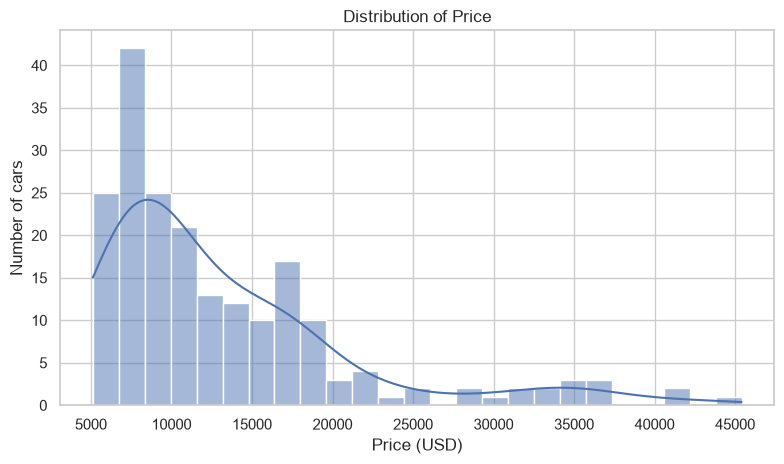

In [20]:
# TODO M2.1: histogram/KDE của price
price_df = df_clean.dropna(subset=["price"]).copy()
fig, ax = plt.subplots(figsize=(8, 4.8))

sns.histplot(
    data=price_df,
    x="price",
    bins=25,
    kde=True,
    ax=ax
)

ax.set_title("Distribution of Price")
ax.set_xlabel("Price (USD)")
ax.set_ylabel("Number of cars")

plt.tight_layout()
plt.show()

**Nhận xét:**
Đồ thị hơi lệch phải, đa số xe nằm ở giá thấp đến trung bình, dự đoán không có phân phối chuẩn

## M2.2 Dataset có cân bằng theo body style không?

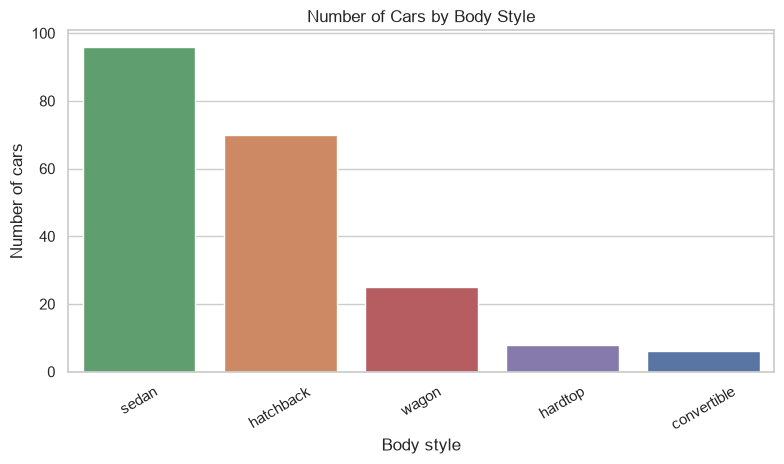

In [21]:
# TODO M2.2: countplot của body_style
body_style_order = df_clean["body_style"].value_counts().index
fig, ax = plt.subplots(figsize=(8, 4.8))

sns.countplot(
    data=df_clean,
    x="body_style",
    order=body_style_order,
    ax=ax,
    hue="body_style"
)

ax.set_title("Number of Cars by Body Style")
ax.set_xlabel("Body style")
ax.set_ylabel("Number of cars")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
- Dataset không cân bằng theo body style.
- Mẫu `sedan` và `hallback` chiếm số lượng nhiều gấn hơn mười lần so với các mẫu như `hardtop` và `convertible`

## M2.3 Price khác nhau theo body style ra sao?

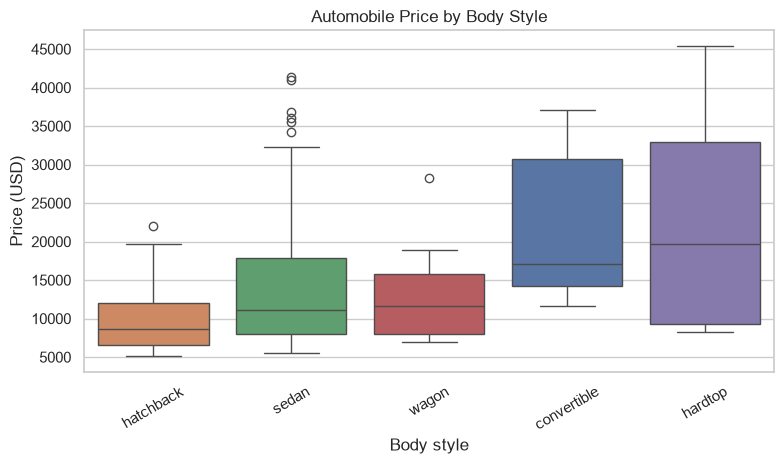

In [22]:
# TODO M2.3: boxplot price theo body_style
price_body_df = df_clean.dropna(subset=["price", "body_style"]).copy()

body_style_order = (
    price_body_df
    .groupby("body_style")["price"]
    .median()
    .sort_values()
    .index
)

fig, ax = plt.subplots(figsize=(8, 4.8))

sns.boxplot(
    data=price_body_df,
    x="body_style",
    y="price",
    order=body_style_order,
    ax=ax,
    hue="body_style"
)

ax.set_title("Automobile Price by Body Style")
ax.set_xlabel("Body style")
ax.set_ylabel("Price (USD)")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
- Có sự khác biệt đáng kể giữa các body style khác nhau về trung vị, phạm vi và giá trị.
- Các mẫu hatchback, sedan và wagon có giá trung bình thấp hơn so với convertible và hardtop.
- Giá của hardtop và convertible có phạm vi rộng, có cả loại rẻ và loại đắt.
- Mẫu sedan có nhiều outlier hơn các mẫu khác.

## M2.4 Engine size liên quan thế nào tới price?

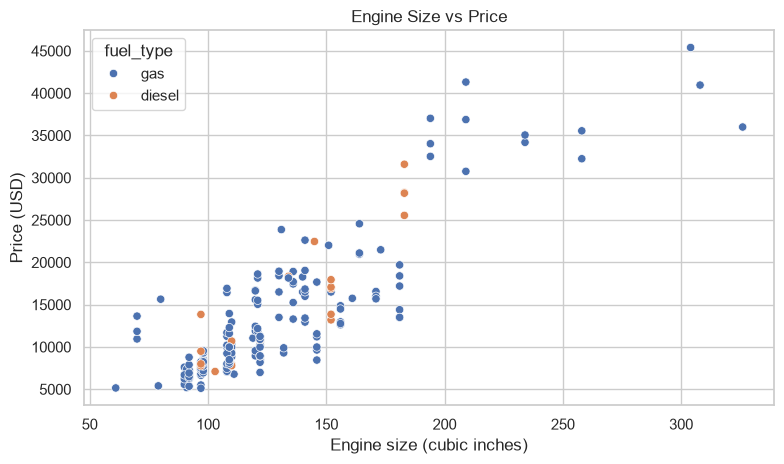

In [23]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type

engine_price_df = df_clean.dropna(
    subset=["engine_size", "price", "fuel_type"]
).copy()

fig, ax = plt.subplots(figsize=(8, 4.8))

sns.scatterplot(
    data=engine_price_df,
    x="engine_size",
    y="price",
    hue="fuel_type",
    ax=ax
)

ax.set_title("Engine Size vs Price")
ax.set_xlabel("Engine size (cubic inches)")
ax.set_ylabel("Price (USD)")

plt.tight_layout()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
- Từ scatterplot ta thấy giữa `engine size` và `price` có mối quan hệ tuyến tính.
- Engine size lớn thì thường có giá cao hơn.

## M2.5 Các feature numeric tương quan ra sao?

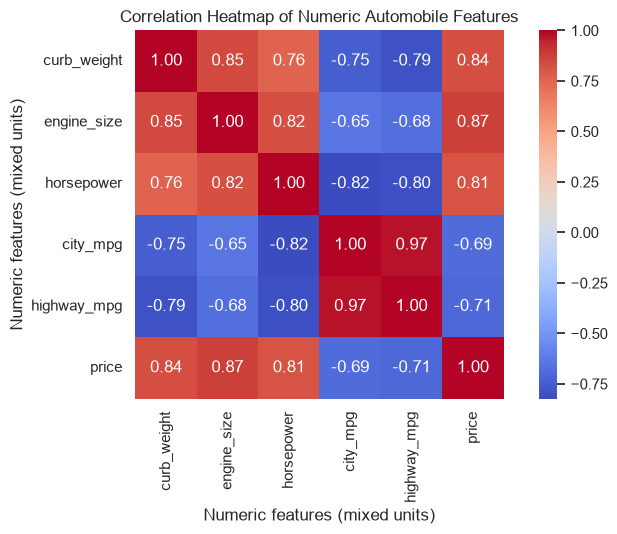

In [24]:
# TODO M2.5: correlation heatmap

corr_cols = [
    "curb_weight",
    "engine_size",
    "horsepower",
    "city_mpg",
    "highway_mpg",
    "price",
]

corr_df = df_clean[corr_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(8, 5.5))

sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    square=True,
    ax=ax,
    cmap='coolwarm'
)

ax.set_title("Correlation Heatmap of Numeric Automobile Features")
ax.set_xlabel("Numeric features (mixed units)")
ax.set_ylabel("Numeric features (mixed units)")

plt.tight_layout()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
- Hệ số tương quan ứng với từng biến độc lập đều khá gần về 2 đầu (`1.00` và `-1.00`), cho thấy các biến này có quan hệ tuyến tính mạnh.
- Các cặp `highway_mpg` và `city_mpg`, `engine_size` và `curb_weight`, `price` và `engine_size` có hệ số tương quan cao (>=0.85), thể hiện rằng các cặp này có quan hệ tuyến tính rất mạnh.

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

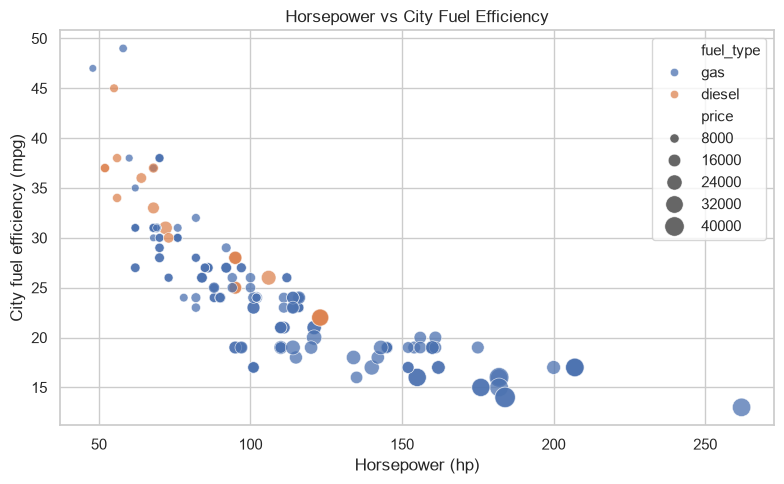

In [25]:
# TODO M2.6: biểu đồ tự chọn
# Câu hỏi: Xe có horsepower cao hơn thì city_mpg thay đổi như thế nào, và price có liên quan gì trong quan hệ này?

horsepower_mpg_df = df_clean.dropna(
    subset=["horsepower", "city_mpg", "price", "fuel_type"]
).copy()

fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=horsepower_mpg_df,
    x="horsepower",
    y="city_mpg",
    hue="fuel_type",
    size="price",
    sizes=(30, 220),
    alpha=0.75,
    ax=ax
)

ax.set_title("Horsepower vs City Fuel Efficiency")
ax.set_xlabel("Horsepower (hp)")
ax.set_ylabel("City fuel efficiency (mpg)")

plt.tight_layout()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
- Xe có horsepower cao thường có city_mpg thấp hơn, cho thấy xe mạnh hơn thường kém tiết kiệm nhiên liệu.
- Các điểm có size lớn hơn thường nằm ở vùng horsepower cao, thể hiện xe đắt hơn thường cũng có công suất lớn hơn.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->

#### Phát hiện:
- Từ histogram ta phát hiện đa số các mẫu xe có giá từ thấp đến trung bình.
- Trong đó, các mẫu hatchback, sedan và wagon chủ yếu thuộc các dòng xe giá rẻ, nhưng vẫn có một số ít các xe giá cao.
- Bộ dataset này có nhiều mẫu xe sedan và hatchback hơn các mẫu còn lại.

#### Hạn chế:
- Bộ dataset có các mẫu xe với số lượng không đều. Một số mẫu chiếm số lượng nhiều hơn hẳn so với các mẫu còn lại.
- Dataset có missing values, đặc biệt normalized_losses thiếu nhiều giá trị, còn price thiếu 4 giá trị nên phải xử lý trước khi phân tích.

#### Correlation và causation:
- Engine_size và price có tương quan dương, nhưng không thể kết luận engine_size trực tiếp làm price tăng. Giá xe còn phụ thuộc vào make, body_style, horsepower, phân khúc xe và nhiều yếu tố khác.

#### Câu hỏi nên phân tích tiếp:
- Aspiration ảnh hưởng thế nào đến horsepower trung bình?